# Compare all server evaluations

This notebook reads the evaluation results below `eva_server/Auswertung_1608` and compares multi-output, two-output, and one-output models in one place.

Ranking and dataset shading now use `soft_dice_whole` (`soft_intensity_dice_whole_mean`) instead of spot recognition. If a model family does not provide a whole-image soft Dice metric, the notebook falls back to `soft_intensity_dice_mean` so one-output models remain comparable.

The special `best_model` evaluation is included as its own row and label.


In [30]:
from pathlib import Path
import re
import textwrap

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
try:
    import pandas as pd
except ImportError as exc:
    raise ImportError("This notebook needs pandas. Install it with: uv add pandas") from exc

## Configuration

In [31]:
EVA_ROOT = Path("eva_server/Auswertung_1608")
OUTPUT_DIR = Path("eva_server/model_comparison/Auswertung_1608_soft_dice_whole")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Ranking is now based on the whole-image soft Dice metric. For model families
# without a whole-image metric, soft_intensity_dice_mean is used as a fallback.
RANK_PRIMARY = "soft_dice_whole_mean"
RANK_PRIMARY_LABEL = "soft Dice whole"
RMSE_WHOLE_METRIC = "rmse_whole_mean"
TOP_N = 3

SPOT_BIN_ORDER = ["<50%", "50-70%", "70-90%", ">90%"]
SPOT_BIN_LABELS = {
    "<50%_fraction": "below 50%",
    "50-70%_fraction": "50-70%",
    "70-90%_fraction": "70-90%",
    ">90%_fraction": "above 90%",
}
SPOT_BIN_COLORS = {
    "<50%_fraction": "#d8e2ee",
    "50-70%_fraction": "#9bb8d4",
    "70-90%_fraction": "#4f86b9",
    ">90%_fraction": "#1f4e79",
}
ARCH_ORDER = ["oneoutput", "twooutput", "pin", "unknown"]
ARCH_COLORS = {
    "oneoutput": "#0072B2",
    "twooutput": "#009E73",
    "pin": "#D55E00",
    "unknown": "#666666",
}
COLOR = {
    "blue": "#0072B2",
    "sky": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "gray": "#666666",
}

MODEL_COLORS = {
    "two-output L1 loss": "#0072B2",
    "two-output L1 loss batch 100": "#E69F00",
    "two-output L1 loss base channel 32": "#009E73",
    "two-output reconstruction loss": "#CC79A7",
    "two-output Tversky loss": "#82A810",
    "two-output Tversky loss small dataset": "#999933",
    "one-output Tversky loss": "#D55E00",
    "one-output Dice/L1 loss": "#F0E442",
    "multi-output BCE/MSE loss": "#6A3D9A",
    "multi-output BCE/MSE loss small dataset": "#A6761D",
    "multi-output Tversky loss base channel 32": "#332288",
    "multi-output Tversky loss batch 100": "#44AA99",
    "multi-output Tversky loss batch 20": "#DDCC77",
    "multi-output Tversky loss learning rate 3e-4": "#AA4499",
    "multi-output Tversky loss learning rate 5e-5": "#117733",
    "multi-output Tversky loss ReduceLROnPlateau 0.5": "#EE7733",
    "multi-output Tversky loss learning rate 1e-4": "#004488",
    "multi-output Tversky loss ReduceLROnPlateau 0.5 evaluation": "#C00000",
}

MODEL_GROUPS = {
    "two-output": [
        "two-output L1 loss",
        "two-output L1 loss batch 100",
        "two-output L1 loss base channel 32",
        "two-output reconstruction loss",
        "two-output Tversky loss",
        "two-output Tversky loss small dataset",
    ],
    "one-output": [
        "one-output Dice/L1 loss",
        "one-output Tversky loss",
    ],
    "multi-output": [
        "multi-output BCE/MSE loss",
        "multi-output BCE/MSE loss small dataset",
        "multi-output Tversky loss base channel 32",
        "multi-output Tversky loss batch 100",
        "multi-output Tversky loss batch 20",
        "multi-output Tversky loss learning rate 3e-4",
        "multi-output Tversky loss learning rate 5e-5",
        "multi-output Tversky loss ReduceLROnPlateau 0.5",
        "multi-output Tversky loss learning rate 1e-4",
        "multi-output Tversky loss ReduceLROnPlateau 0.5 evaluation",
    ],
}

TOTAL_COMPARE_MODELS = [
    "multi-output Tversky loss ReduceLROnPlateau 0.5 evaluation",
    "multi-output Tversky loss learning rate 1e-4",
    "multi-output Tversky loss ReduceLROnPlateau 0.5",
    "one-output Dice/L1 loss",
    "two-output reconstruction loss",
    "two-output L1 loss base channel 32",
]
DEFAULT_MODEL_COLOR = COLOR["gray"]
THESIS_BLUE_CMAP = "Blues"


def model_color(model_display):
    return MODEL_COLORS.get(model_display, DEFAULT_MODEL_COLOR)


def wrap_model_label(label, width=34):
    return "\n".join(textwrap.wrap(str(label), width=width, break_long_words=False))


def set_model_ticklabels_black(ax, axis="y", wrap_width=None):
    ticklabels = ax.get_yticklabels() if axis == "y" else ax.get_xticklabels()
    for tick in ticklabels:
        if wrap_width is not None:
            tick.set_text(wrap_model_label(tick.get_text(), wrap_width))
        tick.set_color("black")

mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "Latin Modern Roman", "cmr10", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


## Helpers

In [32]:
def savefig(fig, name):
    pdf = FIGURE_DIR / f"{name}.pdf"
    png = FIGURE_DIR / f"{name}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, bbox_inches="tight")
    print(f"saved {pdf}")
    print(f"saved {png}")


def coerce_numeric(df):
    for column in df.columns:
        if df[column].dtype == object:
            converted = pd.to_numeric(df[column], errors="coerce")
            if converted.notna().sum() > 0 and converted.notna().sum() >= df[column].notna().sum() * 0.75:
                df[column] = converted
    return df


def infer_arch_from_path(path, model_name=""):
    text = f"{path} {model_name}".lower()
    if "oneoutput" in text or "one_output" in text:
        return "oneoutput"
    if "twooutput" in text or "twooutputs" in text or "twoouts" in text or "two_output" in text:
        return "twooutput"
    if "pin" in text:
        return "pin"
    return "unknown"


def extract_mmdd_hhmm(*texts):
    joined = " ".join(str(text) for text in texts)
    patterns = [
        r"2026(?P<mm>\d{2})(?P<dd>\d{2})[-_](?P<hh>\d{2})(?P<mi>\d{2})",
        r"(?P<mm>\d{2})(?P<dd>\d{1,2})[-_](?P<hh>\d{2})(?P<mi>\d{2})",
    ]
    for pattern in patterns:
        match = re.search(pattern, joined)
        if match:
            return f"{match.group('mm')}{match.group('dd')}-{match.group('hh')}{match.group('mi')}"
    return None


def model_display_name(model, source_dir, arch):
    stamp = extract_mmdd_hhmm(model, source_dir)
    if stamp is None:
        base = Path(source_dir).name
        return f"{base}_{arch}"
    return f"{stamp}_{arch}"


def make_unique_model_display(display_name, source_dir, ambiguous_labels):
    if display_name in set(ambiguous_labels):
        return f"{display_name}__{Path(source_dir).name}"
    return display_name


def dataset_label(experiment):
    text = str(experiment).replace(".h5", "").replace("_logtif", "")
    if text in {"Al_segvol", "Al"}:
        return "Al"
    if text.startswith("Al_deformed_LoG"):
        return "Al_deformed_LoG"
    if text.startswith("Al_big_grains"):
        return "Al_big_grains"
    if text.startswith("Al_small_grains"):
        return "Al_small_grains"
    if text.startswith("Cu"):
        return "Cu"
    if text.startswith("IN718_twins"):
        return "IN718_twins"
    if text.startswith("Iron_deformed"):
        return "Iron_deformed"
    if text.startswith("Iron"):
        return "Iron"
    if text.startswith("Ti7Al"):
        return "Ti7Al"
    return text


def read_csv_if_nonempty(path):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return coerce_numeric(pd.read_csv(path))
    return pd.DataFrame()


def find_metric_files(root):
    root = Path(root)
    return {
        "model": sorted(root.rglob("*model_separation_metrics_5000.csv")),
        "dataset": sorted(root.rglob("*dataset_separation_metrics_5000.csv")),
        "spot": sorted(root.rglob("*spot_separation_metrics_5000.csv")),
        "counter": sorted(root.rglob("*spot_counter_5000.csv")),
        "timing": sorted(root.rglob("*evaluation_timing_5000.csv")),
        "donor": sorted(root.rglob("*donor_separation_metrics_5000.csv")),
    }


## Load all evaluation CSVs

In [33]:
files = find_metric_files(EVA_ROOT)
for kind, paths in files.items():
    print(f"{kind:8s}: {len(paths)} file(s)")
    for path in paths:
        print("  ", path)

model_frames = []
for path in files["model"]:
    df = read_csv_if_nonempty(path)
    if df.empty:
        continue
    source_dir = str(path.parent)
    df["source_dir"] = source_dir
    df["source_file"] = str(path)
    df["architecture"] = [infer_arch_from_path(source_dir, model) for model in df["model"]]
    df["model_display"] = [model_display_name(model, source_dir, arch) for model, arch in zip(df["model"], df["architecture"])]
    if "experiment" in df.columns:
        df["dataset"] = df["experiment"].map(dataset_label)
    model_frames.append(df)

sample_df = pd.concat(model_frames, ignore_index=True) if model_frames else pd.DataFrame()
if not sample_df.empty:
    if "soft_intensity_dice_whole_mean" in sample_df.columns:
        sample_df["soft_dice_whole_mean"] = sample_df["soft_intensity_dice_whole_mean"]
    elif "soft_intensity_dice_mean" in sample_df.columns:
        sample_df["soft_dice_whole_mean"] = sample_df["soft_intensity_dice_mean"]
    if "soft_intensity_dice_mean" in sample_df.columns:
        sample_df["soft_dice_whole_mean"] = sample_df["soft_dice_whole_mean"].fillna(sample_df["soft_intensity_dice_mean"])
    if "rmse_whole_mean" not in sample_df.columns and "rmse_mean" in sample_df.columns:
        sample_df["rmse_whole_mean"] = sample_df["rmse_mean"]
    elif "rmse_mean" in sample_df.columns:
        sample_df["rmse_whole_mean"] = sample_df["rmse_whole_mean"].fillna(sample_df["rmse_mean"])
AMBIGUOUS_MODEL_LABELS = []
if not sample_df.empty:
    sample_df["model_display_base"] = sample_df["model_display"]
    distinct_runs = sample_df[["model_display", "model", "source_dir"]].drop_duplicates()
    duplicate_counts = distinct_runs.groupby("model_display")["source_dir"].nunique()
    AMBIGUOUS_MODEL_LABELS = duplicate_counts[duplicate_counts > 1].index.tolist()
    sample_df["model_display"] = [
        make_unique_model_display(display, source_dir, AMBIGUOUS_MODEL_LABELS)
        for display, source_dir in zip(sample_df["model_display_base"], sample_df["source_dir"])
    ]

print("sample_df", sample_df.shape)
if AMBIGUOUS_MODEL_LABELS:
    print("Ambiguous model labels were made unique with a folder suffix:", ", ".join(AMBIGUOUS_MODEL_LABELS))
if not sample_df.empty:
    display(sample_df[["model_display", "model_display_base", "architecture", "model", "source_dir"]].drop_duplicates().sort_values("model_display"))


model   : 22 file(s)
   eva_server/evaluation/final_eva/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/oneoutput/0702_oneoutput/oneoutput_model_separation_metrics_5000.csv
   eva_server/evaluation/oneoutput/combined_oneoutput_model_separation_metrics_5000.csv
   eva_server/evaluation/oneoutput/tversky/oneoutput_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/batch20/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/combined_pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/dif_lr/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/dif_lr_original/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/lronplateau/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/lronplateau_2/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/pin2/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/pin_base320722/pin_model_separation_metrics_5000.csv
   eva_

,model_display,model_display_base,architecture,model,source_dir
150000,0630-2045_twooutput__0630_2045_twooutput,0630-2045_twooutput,twooutput,final_20260630-204540_augmented_spot_patches_e...,eva_server/evaluation/twooutput/0630_2045_twoo...
155000,0630-2045_twooutput__0630_2045_twooutputs,0630-2045_twooutput,twooutput,final_20260630-204540_augmented_spot_patches_e...,eva_server/evaluation/twooutput/0630_2045_twoo...
190000,0630-2045_twooutput__twooutput,0630-2045_twooutput,twooutput,0630-2045_twooutput__0630_2045_twooutputs,eva_server/evaluation/twooutput
185000,0630-2045_twooutput__twooutput,0630-2045_twooutput,twooutput,0630-2045_twooutput__0630_2045_twooutput,eva_server/evaluation/twooutput
20000,0702-1451_oneoutput,0702-1451_oneoutput,oneoutput,final_20260702-145153_augmented_spots_train_e2...,eva_server/evaluation/oneoutput/0702_oneoutput
230000,0703-2013_twooutput,0703-2013_twooutput,twooutput,final_20260703-201335_augmented_spot_patches_e...,eva_server/evaluation/twooutput/twooutput
125000,0704-0227_pin,0704-0227_pin,pin,final_20260704-022731_augmented_spot_patches_w...,eva_server/evaluation/pins/pin2
160000,0707-1118_twooutput__0707_twooutputs,0707-1118_twooutput,twooutput,final_20260707-111849_twoouts_augmented_spots_...,eva_server/evaluation/twooutput/0707_twooutputs
165000,0707-1118_twooutput__0707_twooutputs_second_ed...,0707-1118_twooutput,twooutput,final_20260707-111849_twoouts_augmented_spots_...,eva_server/evaluation/twooutput/0707_twooutput...
195000,0707-1118_twooutput__twooutput,0707-1118_twooutput,twooutput,0707-1118_twooutput__0707_twooutputs,eva_server/evaluation/twooutput


## Build model-level summary

In [34]:
def aggregate_model_metrics(sample_df):
    metric_cols = [
        "dice_mean", "iou_mean", "rmse_mean", "rmse_whole_mean", "nrmse_mean", "nrmse_whole_mean",
        "soft_intensity_dice_mean", "soft_intensity_dice_whole_mean",
        "integrated_intensity_abs_relative_error_mean", "spot_recognition_mean", "reconstruction_rmse",
    ]
    metric_cols = [col for col in metric_cols if col in sample_df.columns]
    agg = {col: (col, "mean") for col in metric_cols}
    agg.update({
        "n_samples": ("sample_name", "count"),
        "model": ("model", "first"),
        "model_path": ("model_path", "first"),
        "architecture": ("architecture", "first"),
        "source_dir": ("source_dir", "first"),
        "source_file": ("source_file", "first"),
    })
    summary = sample_df.groupby("model_display").agg(**agg).reset_index()
    if "soft_intensity_dice_whole_mean" in summary.columns:
        summary["soft_dice_whole_mean"] = summary["soft_intensity_dice_whole_mean"]
    elif "soft_intensity_dice_mean" in summary.columns:
        summary["soft_dice_whole_mean"] = summary["soft_intensity_dice_mean"]
    if "soft_intensity_dice_mean" in summary.columns:
        summary["soft_dice_whole_mean"] = summary["soft_dice_whole_mean"].fillna(summary["soft_intensity_dice_mean"])
    if "rmse_whole_mean" not in summary.columns and "rmse_mean" in summary.columns:
        summary["rmse_whole_mean"] = summary["rmse_mean"]
    elif "rmse_mean" in summary.columns:
        summary["rmse_whole_mean"] = summary["rmse_whole_mean"].fillna(summary["rmse_mean"])
    if "spot_recognition_mean" in sample_df.columns:
        p10 = sample_df.groupby("model_display")["spot_recognition_mean"].quantile(0.10).rename("spot_recognition_p10")
        summary = summary.join(p10, on="model_display")
    if "soft_dice_whole_mean" in sample_df.columns:
        p10 = sample_df.groupby("model_display")["soft_dice_whole_mean"].quantile(0.10).rename("soft_dice_whole_p10")
        summary = summary.join(p10, on="model_display")
    if "dice_mean" in sample_df.columns:
        p10 = sample_df.groupby("model_display")["dice_mean"].quantile(0.10).rename("dice_p10")
        summary = summary.join(p10, on="model_display")
    return summary


model_summary = aggregate_model_metrics(sample_df) if not sample_df.empty else pd.DataFrame()

# Attach timing, if available.
timing_frames = []
for path in files["timing"]:
    df = read_csv_if_nonempty(path)
    if df.empty:
        continue
    source_dir = str(path.parent)
    df["source_dir"] = source_dir
    df["architecture"] = [infer_arch_from_path(source_dir, model) for model in df["model"]]
    df["model_display_base"] = [model_display_name(model, source_dir, arch) for model, arch in zip(df["model"], df["architecture"])]
    df["model_display"] = [
        make_unique_model_display(display, source_dir, AMBIGUOUS_MODEL_LABELS)
        for display in df["model_display_base"]
    ]
    timing_frames.append(df)
timing_df = pd.concat(timing_frames, ignore_index=True) if timing_frames else pd.DataFrame()
if not timing_df.empty and not model_summary.empty:
    timing_cols = ["model_display", "total_eval_seconds", "seconds_per_sample", "seconds_per_spot", "samples_per_second", "spots_per_second"]
    timing_cols = [col for col in timing_cols if col in timing_df.columns]
    model_summary = model_summary.merge(timing_df[timing_cols].drop_duplicates("model_display"), on="model_display", how="left")
print(f"Loaded {len(model_summary)} model summary row(s). Summary tables are not exported.")


Loaded 29 model summary row(s). Summary tables are not exported.


## Choose and rename models

Edit this cell to decide which models appear in the tables and figures. Leave `SELECTED_MODELS` empty to use all models. Use the names shown in the `available_models` table.

In [35]:
# --- User selection and renaming ---
# Leave SELECTED_MODELS empty to keep every model found below EVA_ROOT.
SELECTED_MODELS = []

model_renaming = {
    "final_20260709-141342_augmented_spots_train_pin_e200_b10_lr0.0001_s1":
        "multi-output BCE/MSE loss",
    "final_20260721-204034_augmented_spots_train_e200_b100_lr0.0001_s1":
        "multi-output Tversky loss batch 100",
    "final_20260720-153845_augmented_spots_train_e200_b10_lr0.0001_s1":
        "multi-output Tversky loss base channel 32",
    "final_20260704-022731_augmented_spot_patches_with_masks_e200_b10_lr0.0001_s1":
        "multi-output BCE/MSE loss small dataset",
    "final_20260729-043315_augmented_spots_train_e200_b10_lr5e-05_s1":
        "multi-output Tversky loss learning rate 5e-5",
    "final_20260728-073240_augmented_spots_train_e200_b10_lr0.0003_s1":
        "multi-output Tversky loss learning rate 3e-4",
    "final_20260802-123726_augmented_spots_train_e200_b20_lr0.0001_s1":
        "multi-output Tversky loss batch 20",
    "final_20260803-135417_augmented_spots_train_e200_b10_lr0.0001_s1":
        "multi-output Tversky loss learning rate 1e-4",
    "final_20260804-224906_augmented_spots_train_e200_b20_lr0.0002_s1":
        "multi-output Tversky loss ReduceLROnPlateau 0.5",
    "final_20260702-145153_augmented_spots_train_e200_b10_lr0.0001_s1":
        "one-output Dice/L1 loss",
    "final_20260727-152943_oneoutput_augmented_spots_train_e2000_b10_lr0.0001_s1":
        "one-output Tversky loss",
    "final_20260719-084743_augmented_spots_train_e200_b100_lr0.0001_s1":
        "two-output L1 loss batch 100",
    "final_20260721-102717_to_newloss_augmented_spots_train_e200_b10_lr0.0001_s1":
        "two-output reconstruction loss",
    "final_20260721-011126_augmented_spots_train_e200_b10_lr0.0001_s1":
        "two-output L1 loss",
    "final_20260717-084426_augmented_spots_train_e200_b10_lr0.0001_s1":
        "two-output L1 loss base channel 32",
    "final_20260707-111849_twoouts_augmented_spots_train_e200_b10_lr0.0001_s1":
        "two-output Tversky loss",
    "final_20260703-201335_augmented_spot_patches_e200_b10_lr0.0001_s1":
        "two-output Tversky loss small dataset",
    "0804-2249_unknown":
        "multi-output Tversky loss ReduceLROnPlateau 0.5 evaluation",
}
MODEL_RENAMES = model_renaming


def apply_model_selection_and_renaming(df, display_col="model_display"):
    if df.empty or display_col not in df.columns:
        return df.copy()

    out = df.copy()
    if SELECTED_MODELS:
        selected = set(SELECTED_MODELS)
        known = set(out[display_col].dropna().unique()).union(set(out.get("model", pd.Series(dtype=str)).dropna().unique()))
        missing = sorted(selected.difference(known))
        if missing:
            print("Warning: selected model names not found:", ", ".join(missing))
        out = out[out[display_col].isin(selected) | out.get("model", pd.Series(dtype=str)).isin(selected)].copy()

    if MODEL_RENAMES:
        special_best_eval = pd.Series(False, index=out.index)
        if "source_dir" in out.columns:
            special_best_eval = out["source_dir"].astype(str).str.contains("/best_model", regex=False)
        if "model" in out.columns:
            renamed_from_model = out["model"].map(MODEL_RENAMES)
            out.loc[~special_best_eval, display_col] = renamed_from_model.loc[~special_best_eval].fillna(out.loc[~special_best_eval, display_col])
        out[display_col] = out[display_col].replace(MODEL_RENAMES)
        out.loc[special_best_eval, display_col] = "multi-output Tversky loss ReduceLROnPlateau 0.5 evaluation"

    if display_col == "model_display":
        unknown_color_models = sorted(set(out[display_col].dropna().unique()).difference(MODEL_COLORS))
        if unknown_color_models:
            print("Dropping selected models without MODEL_COLORS entries:", ", ".join(unknown_color_models))
        out = out[out[display_col].isin(MODEL_COLORS)].copy()
        out["model_color"] = out[display_col].map(model_color)

    return out


def ordered_models_present(model_names, df):
    if df.empty or "model_display" not in df.columns:
        return []
    present = set(df["model_display"].dropna().unique())
    return [name for name in model_names if name in present]


def subset_for_models(df, model_names):
    names = ordered_models_present(model_names, df)
    out = df[df["model_display"].isin(names)].copy()
    if out.empty:
        return out
    order = {name: i for i, name in enumerate(names)}
    out["_model_order"] = out["model_display"].map(order)
    return out.sort_values("_model_order").drop(columns="_model_order")


def show_selected_model_names(df, display_col="model_display"):
    names = sorted(df[display_col].dropna().unique()) if display_col in df.columns else []
    print(f"Using {len(names)} model(s):")
    for name in names:
        print(" -", name)


available_cols = ["model_display", "architecture", "model", "source_dir"]
available_cols = [col for col in available_cols if col in model_summary.columns]
available_models = model_summary[available_cols].drop_duplicates().sort_values("model_display")
display(available_models)

if "model_summary_all" not in globals():
    model_summary_all = model_summary.copy()
if "sample_df_all" not in globals():
    sample_df_all = sample_df.copy()
if "timing_df_all" not in globals():
    timing_df_all = timing_df.copy() if "timing_df" in globals() else pd.DataFrame()

model_summary = apply_model_selection_and_renaming(model_summary_all)
sample_df = apply_model_selection_and_renaming(sample_df_all)
timing_df = apply_model_selection_and_renaming(timing_df_all)

if SELECTED_MODELS and model_summary.empty:
    raise ValueError("SELECTED_MODELS removed every model. Check the names in available_models above.")

renamed_counts = model_summary["model_display"].value_counts() if "model_display" in model_summary.columns else pd.Series(dtype=int)
duplicate_renames = renamed_counts[renamed_counts > 1]
if not duplicate_renames.empty:
    print("Warning: these display names are duplicated after renaming:")
    display(duplicate_renames.rename("count").reset_index().rename(columns={"index": "model_display"}))

show_selected_model_names(model_summary)


,model_display,architecture,model,source_dir
0,0630-2045_twooutput__0630_2045_twooutput,twooutput,final_20260630-204540_augmented_spot_patches_e...,eva_server/evaluation/twooutput/0630_2045_twoo...
1,0630-2045_twooutput__0630_2045_twooutputs,twooutput,final_20260630-204540_augmented_spot_patches_e...,eva_server/evaluation/twooutput/0630_2045_twoo...
2,0630-2045_twooutput__twooutput,twooutput,0630-2045_twooutput__0630_2045_twooutput,eva_server/evaluation/twooutput
3,0702-1451_oneoutput,oneoutput,final_20260702-145153_augmented_spots_train_e2...,eva_server/evaluation/oneoutput/0702_oneoutput
4,0703-2013_twooutput,twooutput,final_20260703-201335_augmented_spot_patches_e...,eva_server/evaluation/twooutput/twooutput
5,0704-0227_pin,pin,final_20260704-022731_augmented_spot_patches_w...,eva_server/evaluation/pins/pin2
6,0707-1118_twooutput__0707_twooutputs,twooutput,final_20260707-111849_twoouts_augmented_spots_...,eva_server/evaluation/twooutput/0707_twooutputs
7,0707-1118_twooutput__0707_twooutputs_second_ed...,twooutput,final_20260707-111849_twoouts_augmented_spots_...,eva_server/evaluation/twooutput/0707_twooutput...
8,0707-1118_twooutput__twooutput,twooutput,0707-1118_twooutput__0707_twooutputs,eva_server/evaluation/twooutput
9,0709-1413_pin,pin,final_20260709-141342_augmented_spots_train_pi...,eva_server/evaluation/pins/pin2


Using 16 model(s):
 - multi-output BCE/MSE loss
 - multi-output Tversky loss ReduceLROnPlateau 0.5
 - multi-output Tversky loss ReduceLROnPlateau 0.5 evaluation
 - multi-output Tversky loss base channel 32
 - multi-output Tversky loss batch 100
 - multi-output Tversky loss batch 20
 - multi-output Tversky loss learning rate 1e-4
 - multi-output Tversky loss learning rate 3e-4
 - multi-output Tversky loss learning rate 5e-5
 - one-output Dice/L1 loss
 - one-output Tversky loss
 - two-output L1 loss
 - two-output L1 loss base channel 32
 - two-output L1 loss batch 100
 - two-output reconstruction loss
 - two-output Tversky loss


## Sanity checks

In [36]:
if sample_df.empty:
    raise ValueError(f"No model metrics found below {EVA_ROOT}")

# Same display name can happen if two folders/models share the same timestamp and architecture.
display_counts = model_summary["model_display"].value_counts()
ambiguous_displays = display_counts[display_counts > 1]
if not ambiguous_displays.empty:
    print("Ambiguous display names found. Consider adding a suffix manually:")
    display(model_summary[model_summary["model_display"].isin(ambiguous_displays.index)][["model_display", "model", "source_dir"]])
else:
    print("No duplicated display names.")

required = ["dice_mean", "iou_mean", "rmse_mean", "spot_recognition_mean"]
missing_by_model = []
for _, row in model_summary.iterrows():
    missing = [col for col in required if col not in model_summary.columns or pd.isna(row.get(col))]
    if missing:
        missing_by_model.append({"model_display": row["model_display"], "missing": ", ".join(missing)})
if missing_by_model:
    print("Models with missing core metrics:")
    display(pd.DataFrame(missing_by_model))
else:
    print("All models have the core comparison metrics.")

No duplicated display names.
All models have the core comparison metrics.


## Ranking and Top 3

In [ ]:
rank_df = model_summary.copy()
rank_df = rank_df.dropna(subset=[RANK_PRIMARY])
rank_df = rank_df.sort_values(
    by=[RANK_PRIMARY, "rmse_whole_mean", "dice_mean", "iou_mean", "nrmse_mean"],
    ascending=[False, True, False, False, True],
).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)
rank_columns = [
    "rank", "model_display", "architecture", "soft_dice_whole_mean", "rmse_whole_mean",
    "spot_recognition_mean", "dice_mean", "iou_mean", "rmse_mean", "nrmse_mean",
    "soft_intensity_dice_mean", "soft_intensity_dice_whole_mean",
    "integrated_intensity_abs_relative_error_mean", "seconds_per_sample", "n_samples", "model", "source_dir",
]
rank_columns = [col for col in rank_columns if col in rank_df.columns]
top3 = rank_df.head(TOP_N)[rank_columns]
rank_df[rank_columns].to_csv(OUTPUT_DIR / "model_ranking.csv", index=False)
top3.to_csv(OUTPUT_DIR / "top3_models.csv", index=False)
model_summary[rank_columns[1:]].to_csv(OUTPUT_DIR / "all_model_summary.csv", index=False)
print(f"Ranked {len(rank_df)} selected model(s) by {RANK_PRIMARY_LABEL}.")
display(top3)


## Figure 1: Overall model ranking

In [ ]:
plot_df = subset_for_models(rank_df, TOTAL_COMPARE_MODELS).sort_values(RANK_PRIMARY, ascending=True)
if plot_df.empty:
    raise ValueError("None of the TOTAL_COMPARE_MODELS are available in rank_df.")

plot_labels = [wrap_model_label(name, width=32) for name in plot_df["model_display"]]
fig, ax = plt.subplots(figsize=(11.5, max(4.6, 0.72 * len(plot_df) + 2.0)), constrained_layout=True)
colors = plot_df["model_display"].map(model_color)
ax.barh(plot_labels, plot_df[RANK_PRIMARY], color=colors)
ax.set_xlabel(RANK_PRIMARY_LABEL)
ax.set_ylabel("model")
ax.set_xlim(0, max(1.0, plot_df[RANK_PRIMARY].max() * 1.05))
ax.set_title("Ranking of different models")
for label, (_, row) in zip(plot_labels, plot_df.iterrows()):
    ax.text(row[RANK_PRIMARY] + 0.005, label, f"{row[RANK_PRIMARY]:.3f}", va="center", fontsize=12)
for tick in ax.get_yticklabels():
    tick.set_color("black")
handles = [plt.Line2D([0], [0], color=model_color(name), lw=7, label=wrap_model_label(name, width=36)) for name in plot_df["model_display"]]
ax.legend(
    handles=handles,
    title="model",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    borderaxespad=0.0,
    handlelength=1.8,
    columnspacing=1.4,
)
savefig(fig, "figure_01_model_ranking_total_compare")
plt.show()


In [ ]:
# Figure 3 is intentionally disabled for the thesis export set.
# Requested outputs are Figure 1, grouped Figure 4/5 PDFs, and Figure 6.
print("Skipping Figure 3 metric comparison export.")


## Figure 4: Dataset-level comparison

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/twooutputs/figures/figure_04_dataset_model_heatmap_two_output.pdf


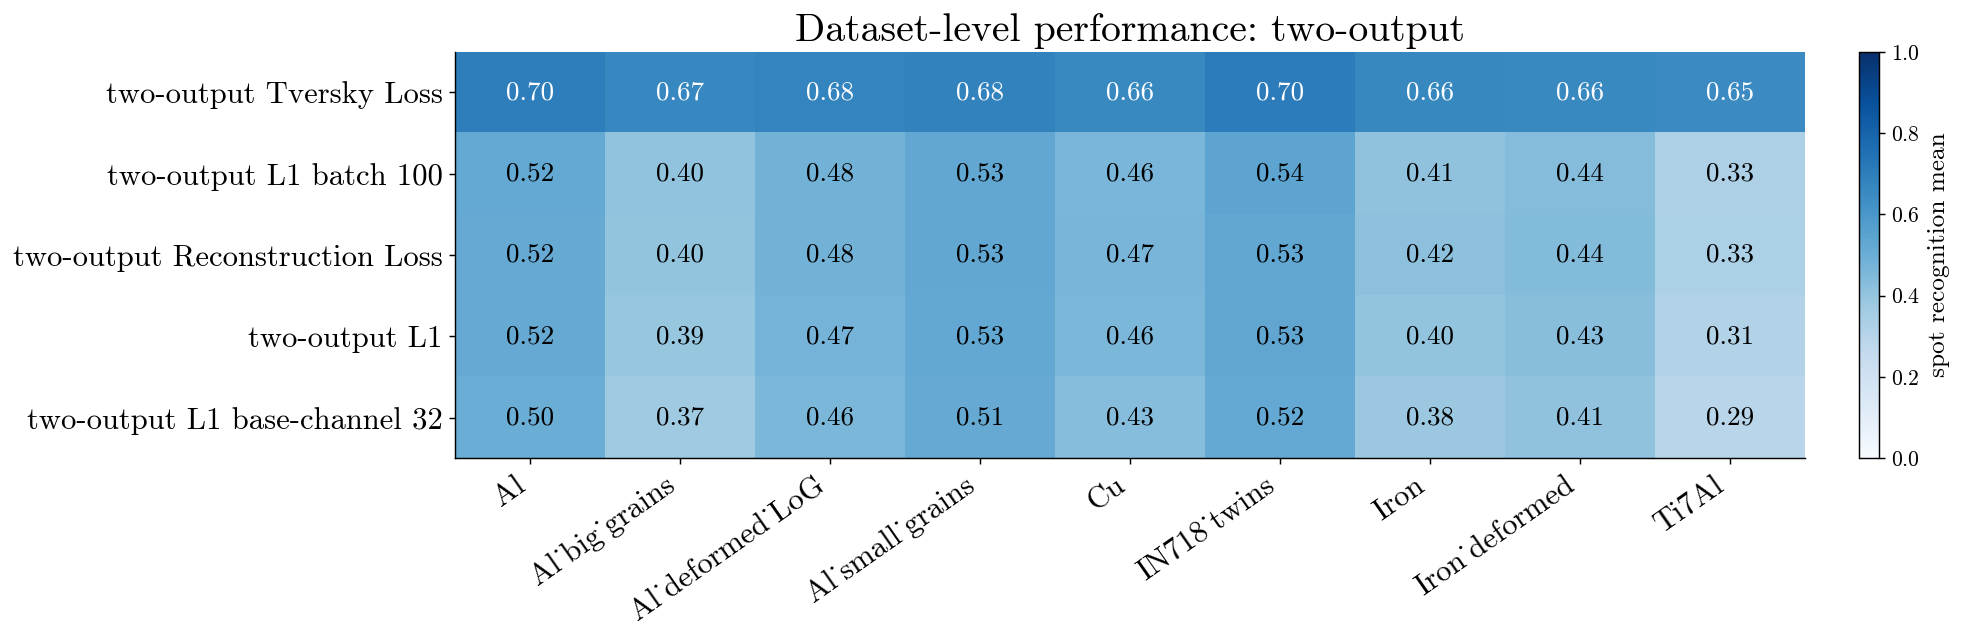

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/twooutputs/figures/figure_04_dataset_model_heatmap_one_output.pdf


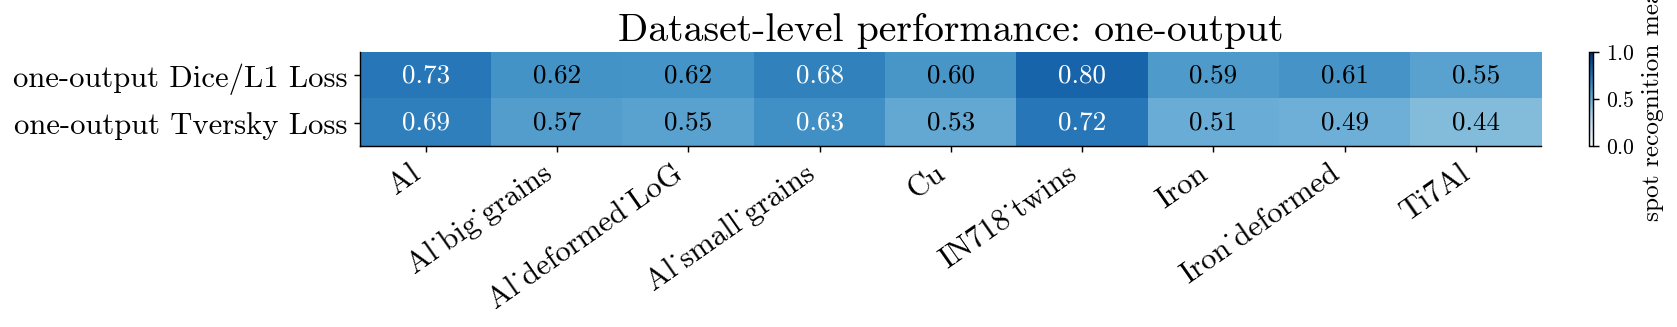

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/twooutputs/figures/figure_04_dataset_model_heatmap_multi_head.pdf


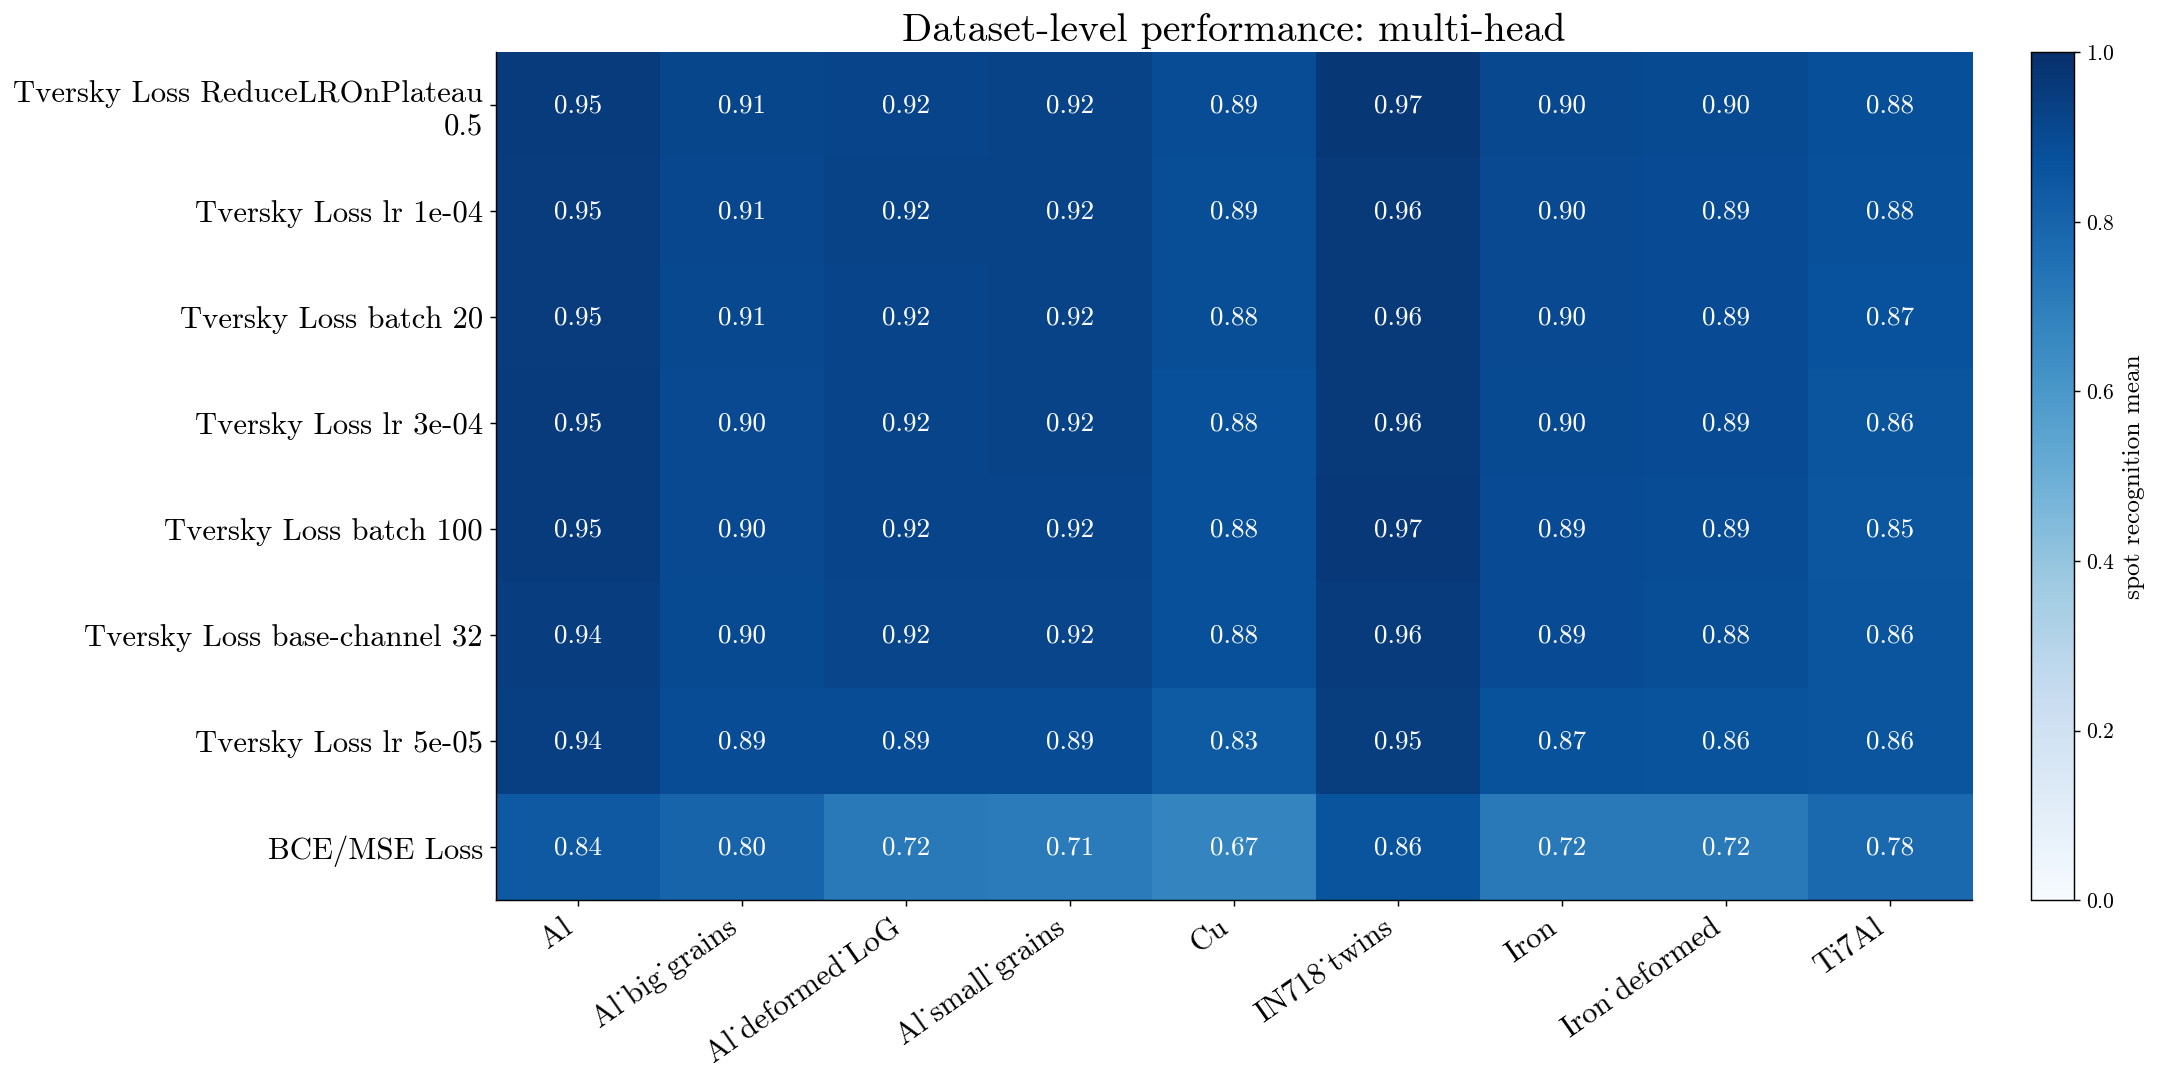

In [43]:
if "dataset" in sample_df.columns:
    dataset_metrics = [RANK_PRIMARY, RMSE_WHOLE_METRIC]
    missing_metrics = [metric for metric in dataset_metrics if metric not in sample_df.columns]
    if missing_metrics:
        raise ValueError(f"Missing dataset metrics: {missing_metrics}")

    dataset_table = (
        sample_df.groupby(["model_display", "architecture", "dataset"])[dataset_metrics]
        .mean()
        .reset_index()
    )
    dataset_table.to_csv(OUTPUT_DIR / "dataset_soft_dice_whole_rmse_whole.csv", index=False)

    def compact_group_label(label, group_name):
        prefixes = {
            "one-output": "one-output ",
            "two-output": "two-output ",
            "multi-output": "multi-output ",
        }
        return str(label).replace(prefixes.get(group_name, ""), "")

    def dataset_axis_label(label):
        return str(label).replace("_", "\n")

    figure_04_layout = {
        "one-output": {
            "figsize": (20.5, 6.4),
            "row_height": 1.45,
            "annot_fontsize": 20,
            "tick_fontsize": 20,
            "x_tick_fontsize": 18,
            "title_fontsize": 27,
            "xlabel_fontsize": 20,
            "y_wrap": 24,
        },
        "two-output": {
            "figsize": (23.0, 0),
            "row_height": 1.42,
            "annot_fontsize": 20,
            "tick_fontsize": 21,
            "x_tick_fontsize": 18,
            "title_fontsize": 28,
            "xlabel_fontsize": 21,
            "y_wrap": 24,
        },
        "multi-output": {
            "figsize": (32.0, 0),
            "row_height": 2.05,
            "annot_fontsize": 34,
            "tick_fontsize": 35,
            "x_tick_fontsize": 30,
            "title_fontsize": 46,
            "xlabel_fontsize": 34,
            "y_wrap": 18,
        },
    }

    for group_name, group_models in MODEL_GROUPS.items():
        group_rank = subset_for_models(rank_df, group_models).sort_values(RANK_PRIMARY, ascending=False)
        group_order = group_rank["model_display"].tolist()
        if not group_order:
            print(f"No available models for {group_name}.")
            continue

        dice_pivot = dataset_table.pivot(index="model_display", columns="dataset", values=RANK_PRIMARY).reindex(group_order)
        rmse_pivot = dataset_table.pivot(index="model_display", columns="dataset", values=RMSE_WHOLE_METRIC).reindex(group_order)
        layout = figure_04_layout.get(group_name, {"figsize": (23.0, 0), "row_height": 1.42, "annot_fontsize": 20, "tick_fontsize": 21, "x_tick_fontsize": 18, "title_fontsize": 28, "xlabel_fontsize": 21, "y_wrap": 24})
        fig_width = layout["figsize"][0]
        fig_height = max(layout["figsize"][1], 4.4 + layout["row_height"] * len(dice_pivot))
        fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
        im = ax.imshow(dice_pivot, cmap=THESIS_BLUE_CMAP, vmin=0, vmax=1, aspect="auto")
        ax.grid(False)
        x_labels = [dataset_axis_label(label) for label in dice_pivot.columns]
        y_labels = [compact_group_label(label, group_name) for label in dice_pivot.index]
        y_labels = [wrap_model_label(label, width=layout["y_wrap"]) for label in y_labels]
        ax.set_xticks(range(len(dice_pivot.columns)), x_labels, rotation=0, ha="center", fontsize=layout["x_tick_fontsize"])
        ax.set_yticks(range(len(dice_pivot.index)), y_labels, fontsize=layout["tick_fontsize"])
        tick_pad_x = 6 if group_name == "multi-output" else 12
        tick_pad_y = 3 if group_name == "multi-output" else 8
        ax.tick_params(axis="x", pad=tick_pad_x)
        ax.tick_params(axis="y", pad=tick_pad_y)
        for tick in ax.get_yticklabels():
            tick.set_color("black")
        for tick in ax.get_xticklabels():
            tick.set_color("black")
        for y in range(dice_pivot.shape[0]):
            for x in range(dice_pivot.shape[1]):
                dice_value = dice_pivot.iloc[y, x]
                rmse_value = rmse_pivot.iloc[y, x]
                if pd.notna(dice_value):
                    label = f"{dice_value:.2f}\n{rmse_value:.3f}" if pd.notna(rmse_value) else f"{dice_value:.2f}"
                    ax.text(
                        x,
                        y,
                        label,
                        ha="center",
                        va="center",
                        color="white" if dice_value > 0.62 else "black",
                        fontsize=layout["annot_fontsize"],
                        linespacing=1.12,
                    )
        cbar_fraction = 0.014 if group_name == "multi-output" else 0.022
        cbar_pad = 0.010 if group_name == "multi-output" else 0.025
        cbar = fig.colorbar(im, ax=ax, label=RANK_PRIMARY_LABEL, location="right", fraction=cbar_fraction, pad=cbar_pad)
        cbar.ax.tick_params(labelsize=max(14, layout["x_tick_fontsize"] - 2))
        cbar.set_label(RANK_PRIMARY_LABEL, fontsize=layout["xlabel_fontsize"])
        ax.set_title(f"Dataset-level performance: {group_name}", fontsize=layout["title_fontsize"])
        xlabel_pad = 12 if group_name == "multi-output" else 24
        ax.set_xlabel("cell values: soft Dice whole / RMSE whole", labelpad=xlabel_pad, fontsize=layout["xlabel_fontsize"])
        savefig(fig, f"figure_04_dataset_model_heatmap_{group_name.replace('-', '_')}")
        plt.show()
else:
    print("No dataset information available in sample-level metrics.")


## Figure 5: Spot counter comparison

In [ ]:
counter_frames = []
for path in files["counter"]:
    df = read_csv_if_nonempty(path)
    if df.empty:
        continue
    source_dir = str(path.parent)
    df["source_dir"] = source_dir
    df["architecture"] = [infer_arch_from_path(source_dir, model) for model in df["model"]]
    df["model_display_base"] = [model_display_name(model, source_dir, arch) for model, arch in zip(df["model"], df["architecture"])]
    df["model_display"] = [
        make_unique_model_display(display, source_dir, AMBIGUOUS_MODEL_LABELS)
        for display in df["model_display_base"]
    ]
    counter_frames.append(df)
counter_df = pd.concat(counter_frames, ignore_index=True) if counter_frames else pd.DataFrame()
if not counter_df.empty:
    counter_df = apply_model_selection_and_renaming(counter_df)

if not counter_df.empty:
    frac_cols = [f"{bin_name}_fraction" for bin_name in SPOT_BIN_ORDER if f"{bin_name}_fraction" in counter_df.columns]

    def compact_counter_label(label, group_name):
        prefixes = {
            "one-output": "one-output ",
            "two-output": "two-output ",
            "multi-output": "multi-output ",
        }
        return wrap_model_label(str(label).replace(prefixes.get(group_name, ""), ""), width=30)

    for group_name, group_models in MODEL_GROUPS.items():
        group_rank = subset_for_models(rank_df, group_models).sort_values(RANK_PRIMARY, ascending=False)
        performance_order = group_rank["model_display"].tolist()
        if not performance_order:
            print(f"No available models for {group_name}.")
            continue

        counter_plot = counter_df.set_index("model_display").reindex(performance_order)[frac_cols].fillna(0)
        y_labels = [compact_counter_label(label, group_name) for label in counter_plot.index]
        fig, ax = plt.subplots(figsize=(12.8, max(3.8, 0.68 * len(counter_plot))), constrained_layout=True)
        left = np.zeros(len(counter_plot))
        y_positions = np.arange(len(counter_plot))
        for col in frac_cols:
            ax.barh(
                y_positions,
                counter_plot[col],
                left=left,
                color=SPOT_BIN_COLORS.get(col, COLOR["gray"]),
                label=SPOT_BIN_LABELS.get(col, col.replace("_fraction", "")),
                edgecolor="white",
                linewidth=0.4,
            )
            left += counter_plot[col].to_numpy()
        ax.set_yticks(y_positions, y_labels, fontsize=14)
        ax.set_xlim(0, 1)
        ax.set_xlabel("fraction of spots", fontsize=15)
        ax.set_title(f"Spot-recognition bin distribution: {group_name}", fontsize=17)
        for tick in ax.get_yticklabels():
            tick.set_color("black")
        legend_y = -0.32 if group_name in {"one-output", "two-output"} else -0.20
        ax.legend(title="spot recognition", loc="upper center", bbox_to_anchor=(0.5, legend_y), ncol=4, borderaxespad=0.0)
        savefig(fig, f"figure_05_spot_counter_{group_name.replace('-', '_')}")
        plt.show()
else:
    print("No spot counter files found.")


## Figure 6: Runtime vs quality

In [ ]:
runtime_df = subset_for_models(rank_df, TOTAL_COMPARE_MODELS)
if "seconds_per_sample" in runtime_df.columns and runtime_df["seconds_per_sample"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    for _, row in runtime_df.dropna(subset=["seconds_per_sample", RANK_PRIMARY]).iterrows():
        ax.scatter(
            row["seconds_per_sample"],
            row[RANK_PRIMARY],
            s=110,
            alpha=0.55,
            color=model_color(row["model_display"]),
            edgecolors="black",
            linewidths=0.6,
            label=row["model_display"],
        )
    ax.set_xlabel("seconds per sample")
    ax.set_ylabel(RANK_PRIMARY_LABEL)
    ax.set_title("Runtime vs quality of selected models")
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    wrapped_labels = [wrap_model_label(label, width=36) for label in unique.keys()]
    ax.legend(unique.values(), wrapped_labels, title="model", loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2, borderaxespad=0.0)
    savefig(fig, "figure_06_runtime_vs_quality_total_compare")
    plt.show()
else:
    print("No timing information available for total-comparison models.")


## Added Figure: Quality vs whole-image RMSE


In [ ]:
tradeoff_df = subset_for_models(rank_df, TOTAL_COMPARE_MODELS)
if not tradeoff_df.empty and {RANK_PRIMARY, RMSE_WHOLE_METRIC}.issubset(tradeoff_df.columns):
    fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    for _, row in tradeoff_df.dropna(subset=[RANK_PRIMARY, RMSE_WHOLE_METRIC]).iterrows():
        ax.scatter(
            row[RMSE_WHOLE_METRIC],
            row[RANK_PRIMARY],
            s=120,
            alpha=0.65,
            color=model_color(row["model_display"]),
            edgecolors="black",
            linewidths=0.6,
            label=row["model_display"],
        )
    ax.set_xlabel("RMSE whole")
    ax.set_ylabel(RANK_PRIMARY_LABEL)
    ax.set_title("Quality trade-off of selected models")
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    wrapped_labels = [wrap_model_label(label, width=36) for label in unique.keys()]
    ax.legend(unique.values(), wrapped_labels, title="model", loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2, borderaxespad=0.0)
    savefig(fig, "figure_07_soft_dice_vs_rmse_whole_total_compare")
    plt.show()
else:
    print("No soft Dice / RMSE whole trade-off data available.")
